In [131]:
import pandas as pd
import numpy as np

data_df = pd.read_csv('Advertising.csv', index_col=0)

In [132]:
data_df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


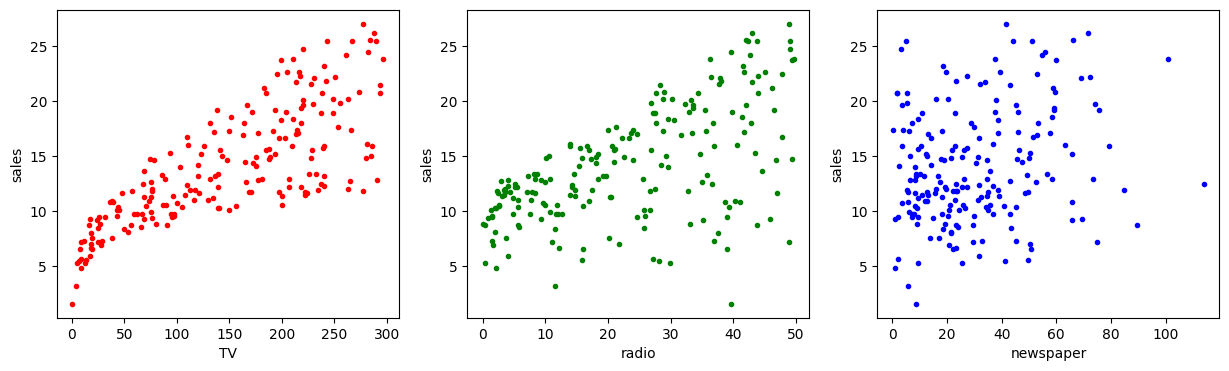

In [133]:
import matplotlib as mpl
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3)

# Plot of sales vs TV
ax = fig.add_subplot(gs[0])
ax.scatter(data_df["TV"], data_df["sales"], color="red", marker=".")
ax.set_xlabel("TV")
ax.set_ylabel("sales")

# Plot of sales vs radio
ax = fig.add_subplot(gs[1])
ax.scatter(data_df["radio"], data_df["sales"], color="green", marker=".")
ax.set_xlabel("radio")
ax.set_ylabel("sales")

# Plot of sales vs newspaper
ax = fig.add_subplot(gs[2])
ax.scatter(data_df["newspaper"], data_df["sales"], color="blue", marker=".")
ax.set_xlabel("newspaper")
ax.set_ylabel("sales")

plt.show()

In [134]:
x = data_df.TV.to_numpy()
y = data_df.sales.to_numpy()

In [135]:
x_mean = x.mean()
y_mean = y.mean()

remaining code....

In [136]:
beta_1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum(np.power((x - x_mean), 2))
beta_1.round(5)

np.float64(0.04754)

In [137]:
beta_0 = y_mean - (beta_1 * x_mean)
beta_0.round(5)

np.float64(7.03259)

In [138]:
print(f'y = {round(beta_0, 3)} + {round(beta_1, 3)} x')

y = 7.033 + 0.048 x


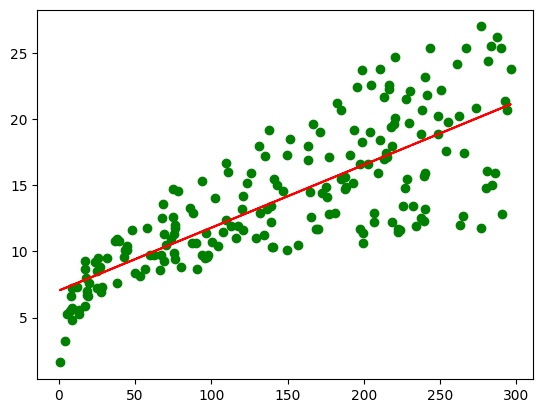

In [139]:
plt.scatter(x, y, color = 'green')
plt.plot(x, beta_0 + (beta_1 * x), color = 'red')

In [140]:
y_hat = beta_0 + (beta_1 * x)

In [141]:
sse = np.sum((y - y_hat) ** 2)

In [142]:
sse.round(5)

np.float64(2102.53058)

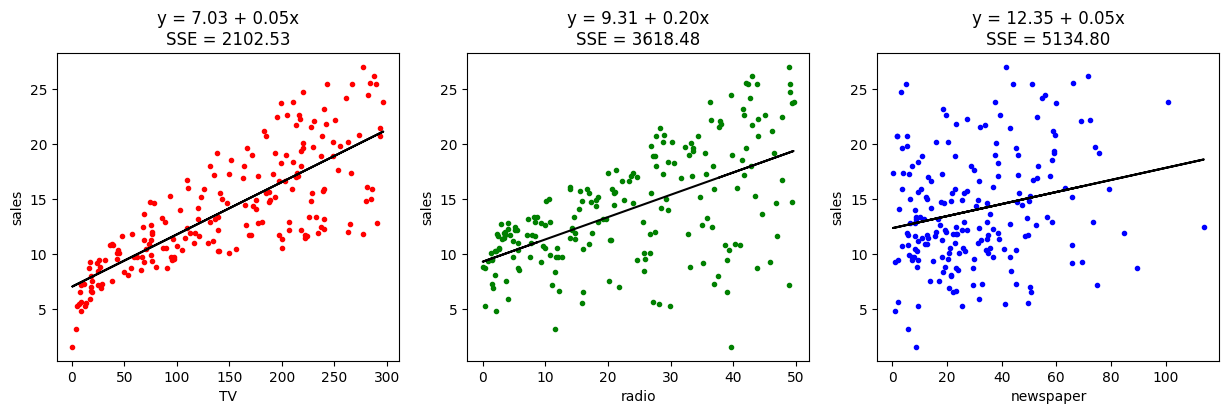

In [143]:
# Collective Data Collection
fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3)

def train_plot(data_df, feature, ax, c):
    
    X = data_df[feature].to_numpy()
    Y = data_df['sales'].to_numpy()

    # Mean
    x_mean = X.mean()
    y_mean = Y.mean()

    # Coefficients
    beta_1 = np.sum((X - x_mean) * (Y - y_mean)) / np.sum((X - x_mean) ** 2)

    beta_0 = y_mean - (beta_1 * x_mean)

    # Predicted values
    y_hat = beta_0 + beta_1 * X

    # SSE
    sse = np.sum((Y - y_hat) ** 2)

    # Plot
    ax.scatter(X, Y, color=c, marker='.')
    ax.plot(X, y_hat, color='black')

    ax.set_xlabel(feature)
    ax.set_ylabel("sales")

    ax.set_title(
        f"y = {beta_0:.2f} + {beta_1:.2f}x\nSSE = {sse:.2f}"
    )

# TV
ax0 = fig.add_subplot(gs[0])
train_plot(data_df, "TV", ax0, "red")

# Radio
ax1 = fig.add_subplot(gs[1])
train_plot(data_df, "radio", ax1, "green")

# Newspaper
ax2 = fig.add_subplot(gs[2])
train_plot(data_df, "newspaper", ax2, "blue")

plt.show()

Another Method 
# SkLearn Implementation

In [144]:
from sklearn.linear_model import LinearRegression

In [145]:
liner_reg = LinearRegression()

In [146]:
liner_reg.fit(x.reshape(-1, 1), y.reshape(-1, 1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [151]:
# Beta1/slope
liner_reg.coef_.round(5)

array([[0.04754]])

In [152]:
# Beta0/Intercept
liner_reg.intercept_.round(5)

array([7.03259])

In [149]:
y_cap = liner_reg.predict(x.reshape(-1, 1))

In [153]:
# Sum of Squared Errors
sse = np.sum((y - y_cap.flatten())**2)
sse.round(5)

np.float64(2102.53058)